In [52]:
pip install pandas matplotlib seaborn nba_api

Note: you may need to restart the kernel to use updated packages.


In [53]:
from nba_api.stats.static import players
from nba_api.stats.endpoints import playercareerstats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get IDs for both players
mj_id = players.find_players_by_full_name('Michael Jordan')[0]['id']
lbj_id = players.find_players_by_full_name('LeBron James')[0]['id']

# 2. Pull career totals
mj_stats = playercareerstats.PlayerCareerStats(player_id=mj_id).get_data_frames()[0]
lbj_stats = playercareerstats.PlayerCareerStats(player_id=lbj_id).get_data_frames()[0]

# 3. Quick Peek
print("Jordan Data Loaded:", mj_stats.shape)
print("LeBron Data Loaded:", lbj_stats.shape)

Jordan Data Loaded: (15, 27)
LeBron Data Loaded: (23, 27)


In [90]:
print(mj_stats.head())

   PLAYER_ID SEASON_ID LEAGUE_ID     TEAM_ID TEAM_ABBREVIATION  PLAYER_AGE  \
0        893   1984-85        00  1610612741               CHI        22.0   
1        893   1985-86        00  1610612741               CHI        23.0   
2        893   1986-87        00  1610612741               CHI        24.0   
3        893   1987-88        00  1610612741               CHI        25.0   
4        893   1988-89        00  1610612741               CHI        26.0   

   GP  GS   MIN   FGM  ...  DREB  REB  AST  STL  BLK  TOV   PF   PTS  \
0  82  82  3144   837  ...   367  534  481  196   69  291  285  2313   
1  18   7   451   150  ...    41   64   53   37   21   45   46   408   
2  82  82  3281  1098  ...   264  430  377  236  125  272  237  3041   
3  82  82  3311  1069  ...   310  449  485  259  131  252  270  2868   
4  81  81  3255   966  ...   503  652  650  234   65  290  247  2633   

           PLAYER  Exp_Year  
0  Michael Jordan         1  
1  Michael Jordan         2  
2  Micha

In [91]:
print(lbj_stats.head())

   PLAYER_ID SEASON_ID LEAGUE_ID     TEAM_ID TEAM_ABBREVIATION  PLAYER_AGE  \
0       2544   2003-04        00  1610612739               CLE        19.0   
1       2544   2004-05        00  1610612739               CLE        20.0   
2       2544   2005-06        00  1610612739               CLE        21.0   
3       2544   2006-07        00  1610612739               CLE        22.0   
4       2544   2007-08        00  1610612739               CLE        23.0   

   GP  GS   MIN  FGM  ...  DREB  REB  AST  STL  BLK  TOV   PF   PTS  \
0  79  79  3120  622  ...   333  432  465  130   58  273  149  1654   
1  80  80  3388  795  ...   477  588  577  177   52  262  146  2175   
2  79  79  3361  875  ...   481  556  521  123   66  260  181  2478   
3  78  78  3190  772  ...   443  526  470  125   55  250  171  2132   
4  75  74  3027  794  ...   459  592  539  138   81  255  165  2250   

         PLAYER  Exp_Year  
0  LeBron James         1  
1  LeBron James         2  
2  LeBron James     

In [95]:
print(mj_stats.describe())

       PLAYER_ID       TEAM_ID  PLAYER_AGE         GP         GS        MIN  \
count       15.0  1.500000e+01   15.000000  15.000000  15.000000    15.0000   
mean       893.0  1.610613e+09   29.800000  71.466667  69.266667  2734.0000   
std          0.0  8.092913e+00    5.595917  22.617524  24.647418   928.6784   
min        893.0  1.610613e+09   22.000000  17.000000   7.000000   451.0000   
25%        893.0  1.610613e+09   25.500000  79.000000  72.500000  3032.5000   
50%        893.0  1.610613e+09   29.000000  82.000000  82.000000  3102.0000   
75%        893.0  1.610613e+09   33.500000  82.000000  82.000000  3189.0000   
max        893.0  1.610613e+09   40.000000  82.000000  82.000000  3311.0000   

               FGM          FGA     FG_PCT        FG3M  ...        OREB  \
count    15.000000    15.000000  15.000000   15.000000  ...   15.000000   
mean    812.800000  1635.800000   0.488267   38.733333  ...  111.200000   
std     301.344179   560.674747   0.042286   38.966041  ...   4

In [93]:
print(lbj_stats.describe())

       PLAYER_ID       TEAM_ID  PLAYER_AGE         GP         GS          MIN  \
count       23.0  2.300000e+01    23.00000  23.000000  23.000000    23.000000   
mean      2544.0  1.610613e+09    30.00000  69.086957  69.000000  2606.173913   
std          0.0  4.270498e+00     6.78233  13.561017  13.591441   616.517614   
min       2544.0  1.610613e+09    19.00000  27.000000  27.000000   902.000000   
25%       2544.0  1.610613e+09    24.50000  64.500000  64.500000  2321.000000   
50%       2544.0  1.610613e+09    30.00000  75.000000  74.000000  2795.000000   
75%       2544.0  1.610613e+09    35.50000  78.500000  78.500000  3040.500000   
max       2544.0  1.610613e+09    41.00000  82.000000  82.000000  3388.000000   

              FGM          FGA     FG_PCT        FG3M  ...        OREB  \
count   23.000000    23.000000  23.000000   23.000000  ...   23.000000   
mean   683.130435  1348.869565   0.508391  113.086957  ...   79.086957   
std    144.433471   297.438199   0.033391   30.9

In [54]:
# Add names to distinguish after merging
mj_stats['PLAYER'] = 'Michael Jordan'
lbj_stats['PLAYER'] = 'LeBron James'

# Create a 'Season_Number' column (Year 1, Year 2, etc.) 
# This is crucial for a fair "age" comparison
mj_stats['Exp_Year'] = range(1, len(mj_stats) + 1)
lbj_stats['Exp_Year'] = range(1, len(lbj_stats) + 1)

df = pd.concat([mj_stats, lbj_stats])

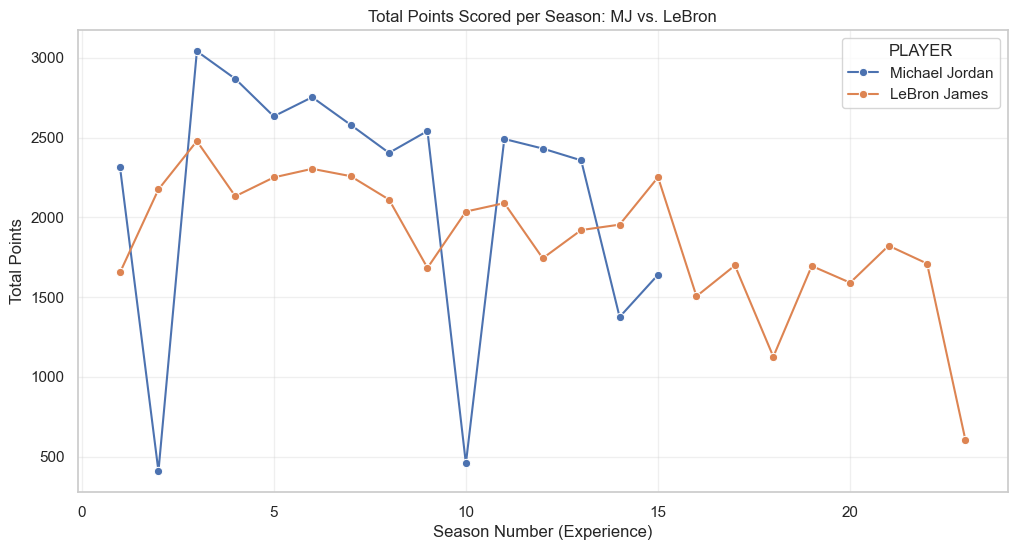

In [87]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Exp_Year', y='PTS', hue='PLAYER', marker='o')
plt.title('Total Points Scored per Season: MJ vs. LeBron')
plt.xlabel('Season Number (Experience)')
plt.ylabel('Total Points')
plt.grid(True, alpha=0.3)
plt.show()

--- Michael Jordan Career Shooting Table ---
SEASON_ID  FGM  FGA  FG_PCT
  1984-85  837 1625   0.515
  1985-86  150  328   0.457
  1986-87 1098 2279   0.482
  1987-88 1069 1998   0.535
  1988-89  966 1795   0.538
  1989-90 1034 1964   0.526
  1990-91  990 1837   0.539
  1991-92  943 1818   0.519
  1992-93  992 2003   0.495
  1994-95  166  404   0.411
  1995-96  916 1850   0.495
  1996-97  920 1892   0.486
  1997-98  881 1893   0.465
  2001-02  551 1324   0.416
  2002-03  679 1527   0.445


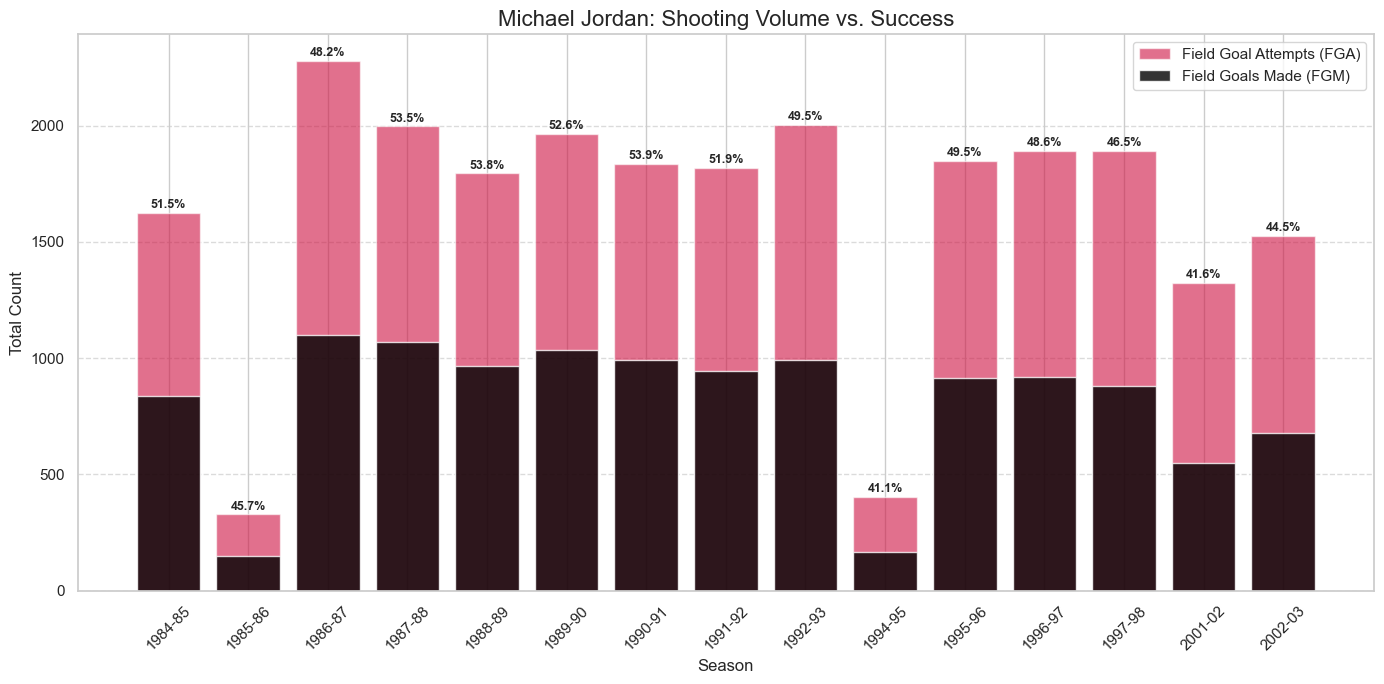

In [56]:
mj_shooting = mj_stats[['SEASON_ID', 'FGM', 'FGA', 'FG_PCT']].copy()

# 3. Print the table to your VS Code terminal/output
print("--- Michael Jordan Career Shooting Table ---")
print(mj_shooting.to_string(index=False))

# 4. Create the Bar Graph
plt.figure(figsize=(14, 7))

# We'll plot Attempts and Makes side-by-side
x_axis = mj_shooting['SEASON_ID']
fga = mj_shooting['FGA']
fgm = mj_shooting['FGM']

plt.bar(x_axis, fga, label='Field Goal Attempts (FGA)', color='#CE1141', alpha=0.6) # Bulls Red
plt.bar(x_axis, fgm, label='Field Goals Made (FGM)', color='#000000', alpha=0.8)   # Black

# Add labels and styling
plt.title('Michael Jordan: Shooting Volume vs. Success', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a little text label for the FG% on top of the bars
for i, pct in enumerate(mj_shooting['FG_PCT']):
    plt.text(i, fga[i] + 20, f'{pct*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

--- LeBron James Career Shooting Table ---
SEASON_ID  FGM  FGA  FG_PCT
  2003-04  622 1492   0.417
  2004-05  795 1684   0.472
  2005-06  875 1823   0.480
  2006-07  772 1621   0.476
  2007-08  794 1642   0.484
  2008-09  789 1613   0.489
  2009-10  768 1528   0.503
  2010-11  758 1485   0.510
  2011-12  621 1169   0.531
  2012-13  765 1354   0.565
  2013-14  767 1353   0.567
  2014-15  624 1279   0.488
  2015-16  737 1416   0.520
  2016-17  736 1344   0.548
  2017-18  857 1580   0.542
  2018-19  558 1095   0.510
  2019-20  643 1303   0.493
  2020-21  422  823   0.513
  2021-22  640 1221   0.524
  2022-23  609 1219   0.500
  2023-24  685 1269   0.540
  2024-25  651 1270   0.513
  2025-26  224  441   0.508


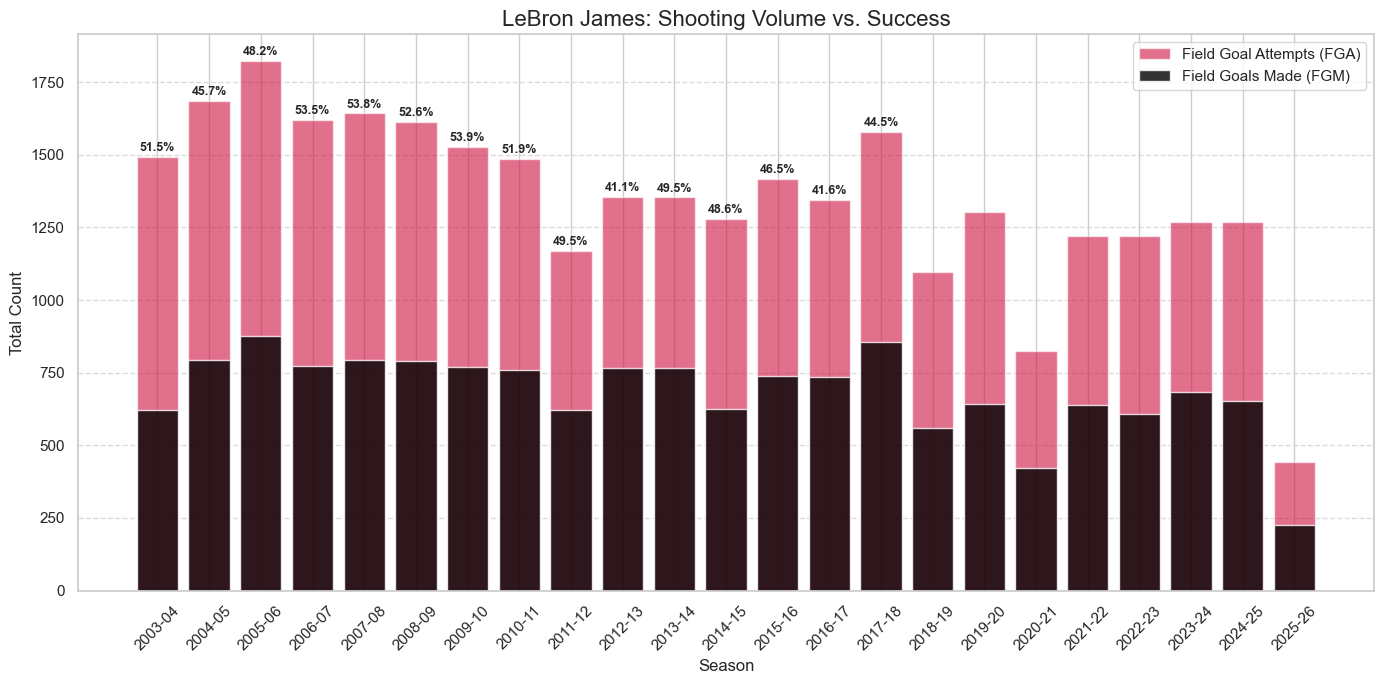

In [57]:
lbj_shooting = lbj_stats[['SEASON_ID', 'FGM', 'FGA', 'FG_PCT']].copy()

# 3. Print the table to your VS Code terminal/output
print("--- LeBron James Career Shooting Table ---")
print(lbj_shooting.to_string(index=False))

# 4. Create the Bar Graph
plt.figure(figsize=(14, 7))

# We'll plot Attempts and Makes side-by-side
x_axis = lbj_shooting['SEASON_ID']
fga = lbj_shooting['FGA']
fgm = lbj_shooting['FGM']

plt.bar(x_axis, fga, label='Field Goal Attempts (FGA)', color='#CE1141', alpha=0.6) # Bulls Red
plt.bar(x_axis, fgm, label='Field Goals Made (FGM)', color='#000000', alpha=0.8)   # Black

# Add labels and styling
plt.title('LeBron James: Shooting Volume vs. Success', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a little text label for the FG% on top of the bars
for i, pct in enumerate(mj_shooting['FG_PCT']):
    plt.text(i, fga[i] + 20, f'{pct*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

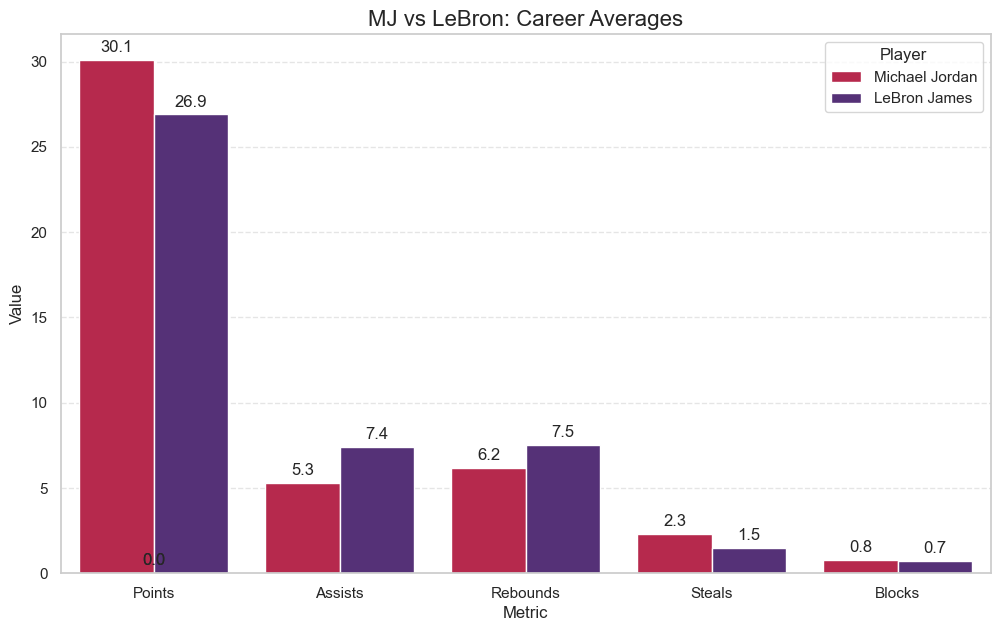

In [74]:
# Assuming you've already pulled the data from the previous steps
# Let's create a summary dataframe for the visual
compare_data = {
    'Metric': ['Points', 'Assists', 'Rebounds', 'Steals', 'Blocks'],
    'Michael Jordan': [30.1, 5.3, 6.2, 2.3, 0.8],
    'LeBron James': [26.9, 7.4, 7.5, 1.5, 0.7] 
}

df_compare = pd.DataFrame(compare_data).melt(id_vars='Metric', var_name='Player', value_name='Value')

# Plotting
plt.figure(figsize=(12, 7))
sns.barplot(data=df_compare, x='Metric', y='Value', hue='Player', palette=['#CE1141', '#552583'])

plt.title('MJ vs LeBron: Career Averages', fontsize=16)
plt.ylabel('Value')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adding the exact numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.show()

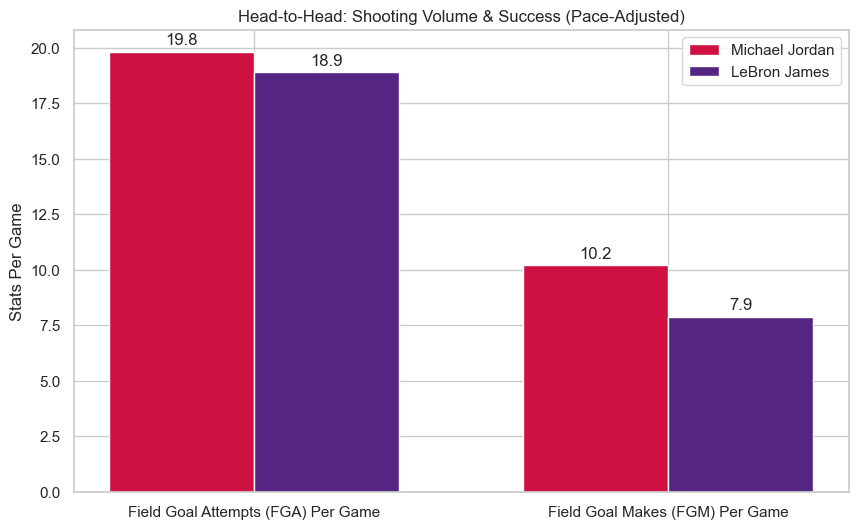

In [89]:
def get_fgm_fga(df):
    # Formula: (Stat / Minutes) * 48 * (100 / Era Pace)
    fga_100 = (df['FGA'] / df['GP'])
    fgm_100 = (df['FGM'] / df['GP'])
    return fga_100, fgm_100

mj_fga, mj_fgm = get_fgm_fga(mj_stats.iloc[0])
lbj_fga, lbj_fgm = get_fgm_fga(lbj_stats.iloc[0])

# 3. Create the Comparison Plot
labels = ['Field Goal Attempts (FGA) Per Game', 'Field Goal Makes (FGM) Per Game']
mj_vals = [mj_fga, mj_fgm]
lbj_vals = [lbj_fga, lbj_fgm]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, mj_vals, width, label='Michael Jordan', color='#CE1141') # Bulls Red
rects2 = ax.bar(x + width/2, lbj_vals, width, label='LeBron James', color='#552583') # Lakers Purple

# Add styling and labels
ax.set_ylabel('Stats Per Game')
ax.set_title('Head-to-Head: Shooting Volume & Success (Pace-Adjusted)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()

--- Michael Jordan: Career 3-Point Shooting ---
SEASON_ID  FG3M  FG3A  FG3_PCT
  1984-85     9    52    0.173
  1985-86     3    18    0.167
  1986-87    12    66    0.182
  1987-88     7    53    0.132
  1988-89    27    98    0.276
  1989-90    92   245    0.376
  1990-91    29    93    0.312
  1991-92    27   100    0.270
  1992-93    81   230    0.352
  1994-95    16    32    0.500
  1995-96   111   260    0.427
  1996-97   111   297    0.374
  1997-98    30   126    0.238
  2001-02    10    53    0.189
  2002-03    16    55    0.291


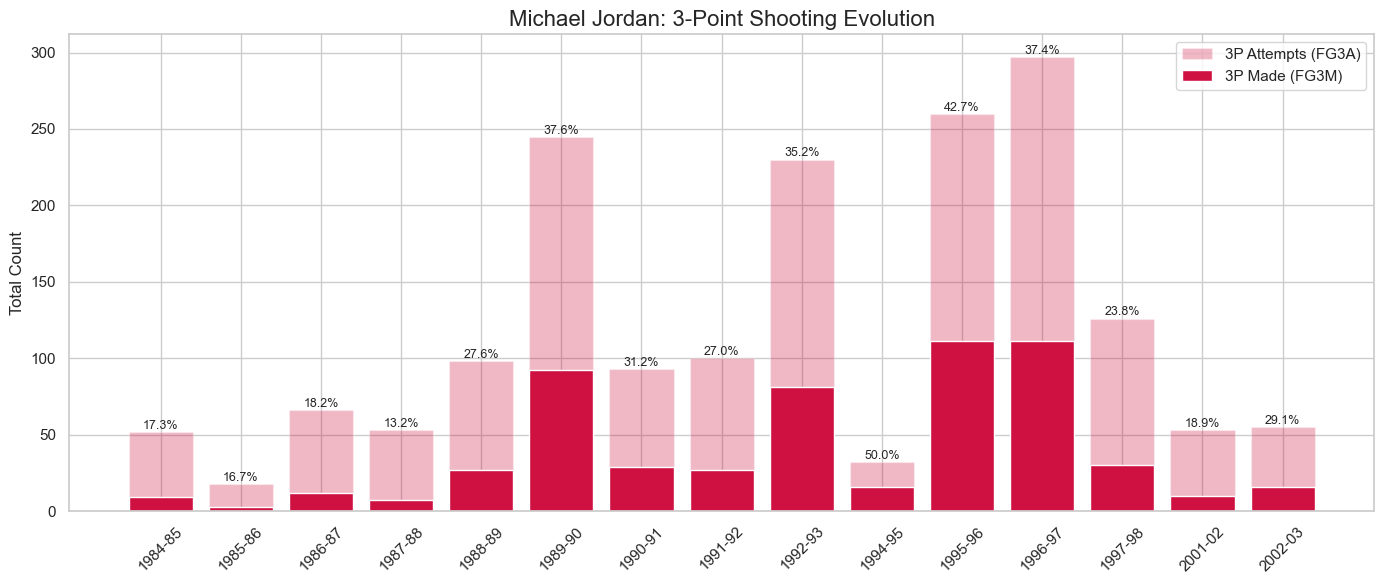

In [60]:
mj_3pt = mj_stats[['SEASON_ID', 'FG3M', 'FG3A', 'FG3_PCT']].copy()

# 3. Print the Table
print("--- Michael Jordan: Career 3-Point Shooting ---")
print(mj_3pt.to_string(index=False))

# 4. Create the Plot
plt.figure(figsize=(14, 6))

# We use a line plot for 3PT% and bars for volume
plt.bar(mj_3pt['SEASON_ID'], mj_3pt['FG3A'], label='3P Attempts (FG3A)', color='#CE1141', alpha=0.3)
plt.bar(mj_3pt['SEASON_ID'], mj_3pt['FG3M'], label='3P Made (FG3M)', color='#CE1141')

plt.title('Michael Jordan: 3-Point Shooting Evolution', fontsize=16)
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend()

# Adding the percentage labels
for i, pct in enumerate(mj_3pt['FG3_PCT']):
    plt.text(i, mj_3pt['FG3A'][i] + 2, f'{pct*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

--- LeBron James: Career 3-Point Shooting ---
SEASON_ID  FG3M  FG3A  FG3_PCT
  2003-04    63   217    0.290
  2004-05   108   308    0.351
  2005-06   127   379    0.335
  2006-07    99   310    0.319
  2007-08   113   359    0.315
  2008-09   132   384    0.344
  2009-10   129   387    0.333
  2010-11    92   279    0.330
  2011-12    54   149    0.362
  2012-13   103   254    0.406
  2013-14   116   306    0.379
  2014-15   120   339    0.354
  2015-16    87   282    0.309
  2016-17   124   342    0.363
  2017-18   149   406    0.367
  2018-19   111   327    0.339
  2019-20   148   425    0.348
  2020-21   104   285    0.365
  2021-22   161   448    0.359
  2022-23   121   377    0.321
  2023-24   149   363    0.410
  2024-25   149   396    0.376
  2025-26    42   127    0.331


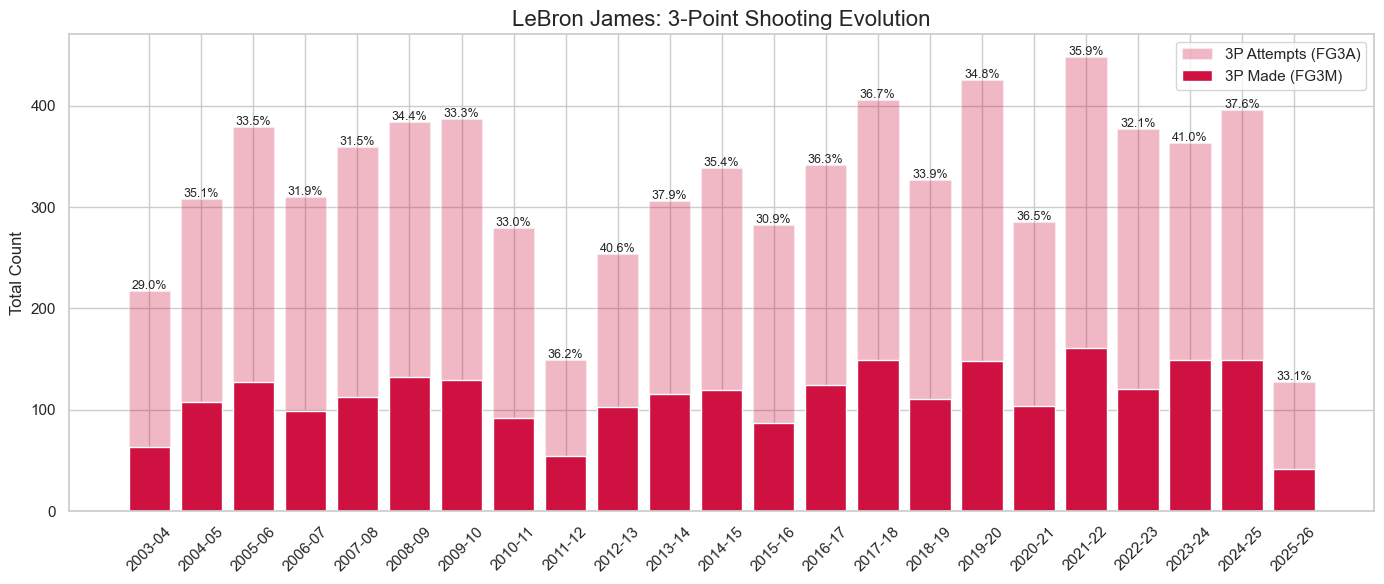

In [61]:
lbj_3pt = lbj_stats[['SEASON_ID', 'FG3M', 'FG3A', 'FG3_PCT']].copy()

# 3. Print the Table
print("--- LeBron James: Career 3-Point Shooting ---")
print(lbj_3pt.to_string(index=False))

# 4. Create the Plot
plt.figure(figsize=(14, 6))

# We use a line plot for 3PT% and bars for volume
plt.bar(lbj_3pt['SEASON_ID'], lbj_3pt['FG3A'], label='3P Attempts (FG3A)', color='#CE1141', alpha=0.3)
plt.bar(lbj_3pt['SEASON_ID'], lbj_3pt['FG3M'], label='3P Made (FG3M)', color='#CE1141')

plt.title('LeBron James: 3-Point Shooting Evolution', fontsize=16)
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend()

# Adding the percentage labels
for i, pct in enumerate(lbj_3pt['FG3_PCT']):
    plt.text(i, lbj_3pt['FG3A'][i] + 2, f'{pct*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

--- Michael Jordan: 3PT Per 100 ---
SEASON_ID  3PM_100  3PA_100  FG3_PCT
  1984-85 0.148545 0.858263    0.173
  1985-86 0.345179 2.071073    0.167
  1986-87 0.189791 1.043848    0.182
  1987-88 0.109708 0.830646    0.132
  1988-89 0.430440 1.562337    0.276
  1989-90 1.493292 3.976701    0.376
  1990-91 0.496000 1.590622    0.312
  1991-92 0.451670 1.672853    0.270
  1992-93 1.370474 3.891469    0.352
  1994-95 1.242920 2.485839    0.500
  1995-96 1.864078 4.366308    0.427
  1996-97 1.852686 4.957186    0.374
  1997-98 0.489392 2.055447    0.238
  2001-02 0.248405 1.316549    0.189
  2002-03 0.273926 0.941621    0.291

--- LeBron James: 3PT Per 100 ---
SEASON_ID  3PM_100   3PA_100  FG3_PCT
  2003-04 0.974101  3.355238    0.290
  2004-05 1.537795  4.385564    0.351
  2005-06 1.822860  5.439874    0.335
  2006-07 1.497141  4.688017    0.319
  2007-08 1.800878  5.721372    0.315
  2008-09 2.085082  6.065692    0.344
  2009-10 2.098151  6.294453    0.333
  2010-11 1.448969  4.394155    0

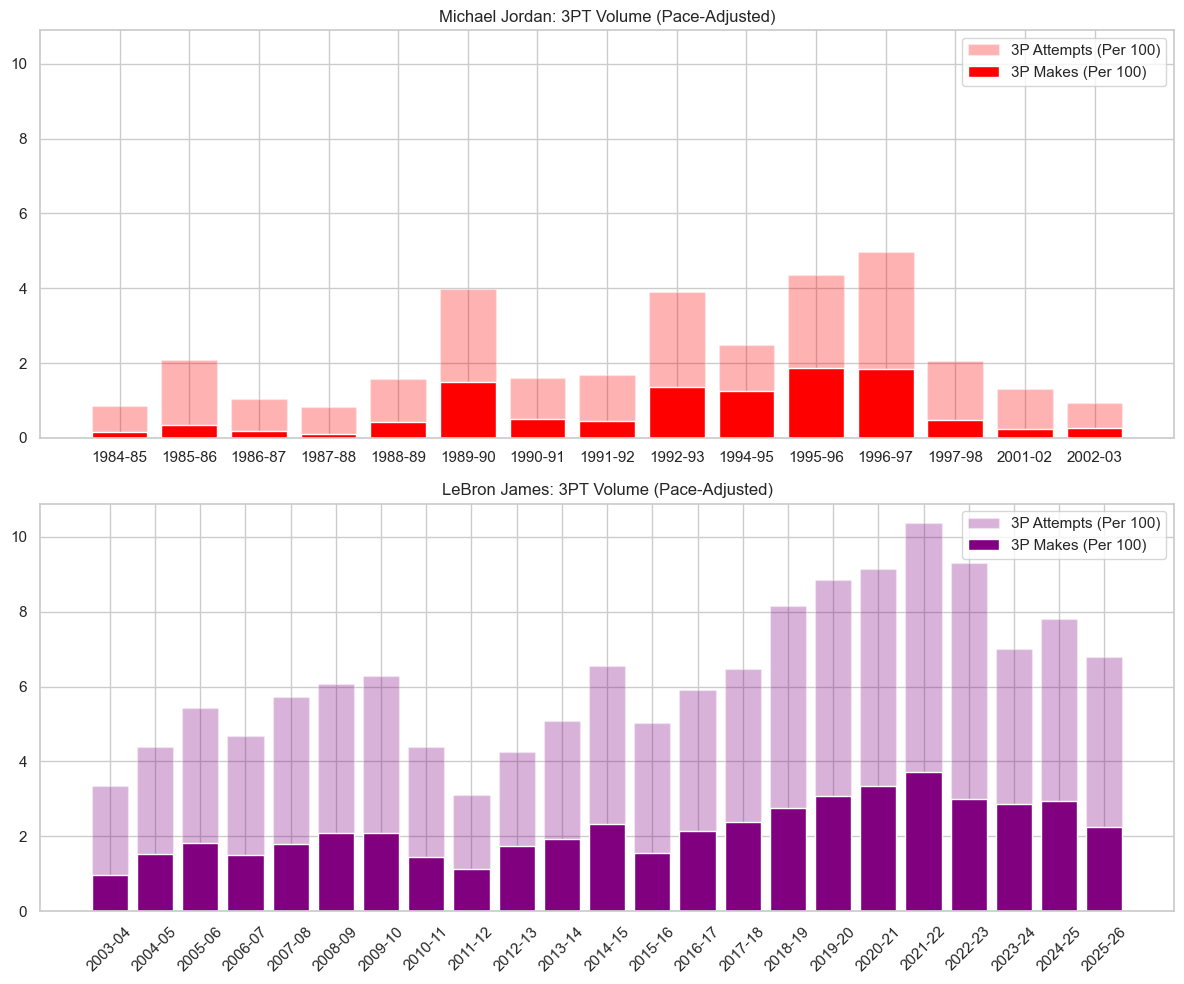

In [62]:
def get_3pt_100(df, era_pace):
    df = df.copy()
    # Formula: (Stat / Minutes) * 48 * (100 / Era Pace)
    df['3PM_100'] = (df['FG3M'] / df['MIN']) * 48 * (100 / era_pace)
    df['3PA_100'] = (df['FG3A'] / df['MIN']) * 48 * (100 / era_pace)
    return df[['SEASON_ID', '3PM_100', '3PA_100', 'FG3_PCT']]

mj_100 = get_3pt_100(mj_stats, 92.5)
lbj_100 = get_3pt_100(lbj_stats, 99.5)

# 3. Print Tables for verification
print("--- Michael Jordan: 3PT Per 100 ---")
print(mj_100.to_string(index=False))
print("\n--- LeBron James: 3PT Per 100 ---")
print(lbj_100.to_string(index=False))

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

# Michael Jordan Plot
ax1.bar(mj_100['SEASON_ID'], mj_100['3PA_100'], color='red', alpha=0.3, label='3P Attempts (Per 100)')
ax1.bar(mj_100['SEASON_ID'], mj_100['3PM_100'], color='red', label='3P Makes (Per 100)')
ax1.set_title('Michael Jordan: 3PT Volume (Pace-Adjusted)')
ax1.legend()

# LeBron James Plot
ax2.bar(lbj_100['SEASON_ID'], lbj_100['3PA_100'], color='purple', alpha=0.3, label='3P Attempts (Per 100)')
ax2.bar(lbj_100['SEASON_ID'], lbj_100['3PM_100'], color='purple', label='3P Makes (Per 100)')
ax2.set_title('LeBron James: 3PT Volume (Pace-Adjusted)')
ax2.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
def get_stats_100(df, era_pace):
    df = df.copy()
    # Normalize key metrics to 100 possessions
    df['PTS_100'] = (df['PTS'] / df['MIN']) * 48 * (100 / era_pace)
    df['FGA_100'] = (df['FGA'] / df['MIN']) * 48 * (100 / era_pace)
    df['FGM_100'] = (df['FGM'] / df['MIN']) * 48 * (100 / era_pace)
    df['3PA_100'] = (df['FG3A'] / df['MIN']) * 48 * (100 / era_pace)
    df['3PM_100'] = (df['FG3M'] / df['MIN']) * 48 * (100 / era_pace)
    return df[['PTS_100', 'FGA_100', 'FGM_100', '3PA_100', '3PM_100', 'FG_PCT', 'FG3_PCT']]

mj_100 = get_stats_100(mj_stats, 92.5)
lbj_100 = get_stats_100(lbj_stats, 99.5)

# 3. Calculate Mean and Standard Deviation
def calculate_summary(df, name):
    mean = df.mean()
    std = df.std()
    
    summary = pd.DataFrame({
        'Metric': mean.index,
        f'{name} Mean': mean.values,
        f'{name} Std Dev': std.values
    })
    return summary

mj_summary = calculate_summary(mj_100, "Jordan")
lbj_summary = calculate_summary(lbj_100, "LeBron")

# 4. Merge and Display
final_comparison = pd.merge(mj_summary, lbj_summary, on='Metric')

print("--- MJ vs LeBron: Consistency & Average Comparison ---")
# Rounding for readability
print(final_comparison.round(2).to_string(index=False))

# Optional: Print a specific insight about consistency
print(f"\nConsistency Insight: Jordan's FGA Std Dev is {final_comparison.iloc[1, 2]:.2f} "
      f"vs LeBron's {final_comparison.iloc[1, 4]:.2f}")

--- MJ vs LeBron: Consistency & Average Comparison ---
 Metric  Jordan Mean  Jordan Std Dev  LeBron Mean  LeBron Std Dev
PTS_100        40.72            5.27        34.63            2.84
FGA_100        31.47            3.02        25.12            1.86
FGM_100        15.35            1.74        12.76            1.13
3PA_100         2.24            1.38         6.27            1.96
3PM_100         0.73            0.64         2.19            0.73
 FG_PCT         0.49            0.04         0.51            0.03
FG3_PCT         0.28            0.11         0.35            0.03

Consistency Insight: Jordan's FGA Std Dev is 3.02 vs LeBron's 1.86


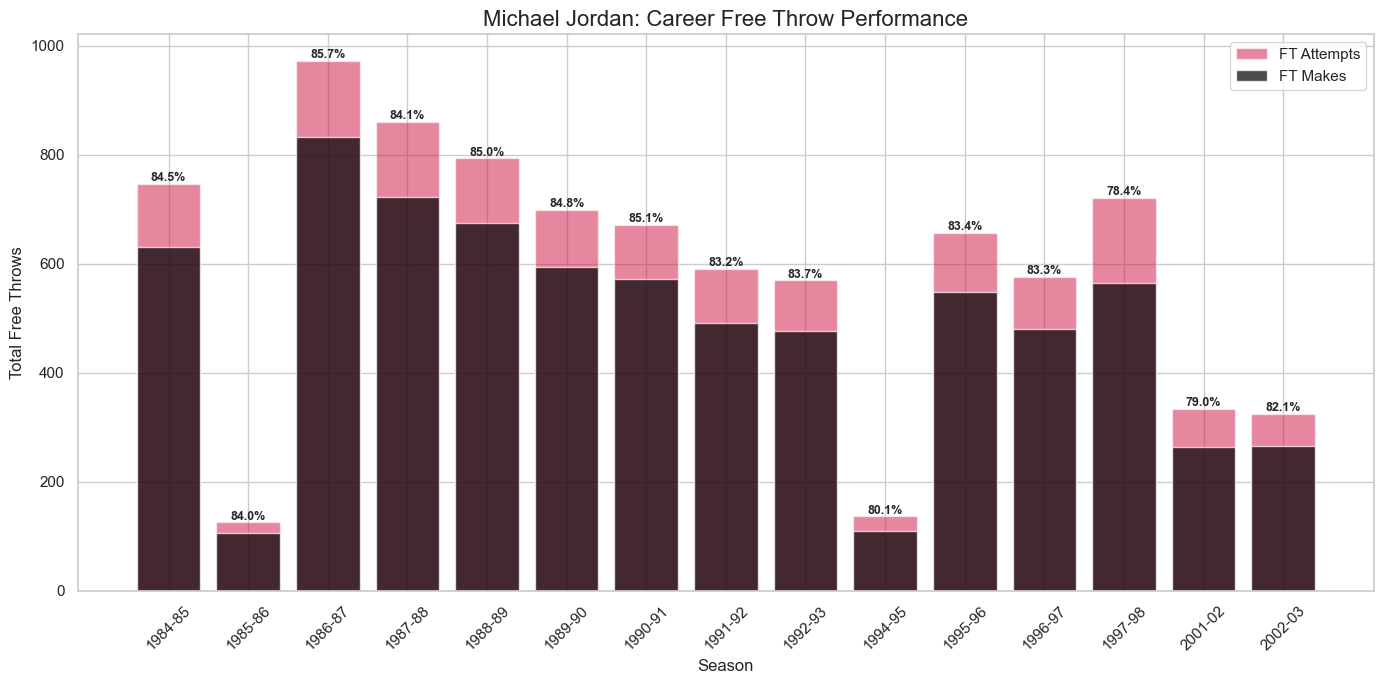

In [64]:
mj_ft = mj_stats[['SEASON_ID', 'FTM', 'FTA', 'FT_PCT']].copy()

# 4. Visualization
plt.figure(figsize=(14, 7))

# Plotting the Volume (Attempts) and Success (Makes)
plt.bar(mj_ft['SEASON_ID'], mj_ft['FTA'], label='FT Attempts', color='#CE1141', alpha=0.5) # Bulls Red
plt.bar(mj_ft['SEASON_ID'], mj_ft['FTM'], label='FT Makes', color='#000000', alpha=0.7)    # Bulls Black

plt.title('Michael Jordan: Career Free Throw Performance', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Free Throws', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

# Add FT% as text labels on top of the bars
for i, pct in enumerate(mj_ft['FT_PCT']):
    plt.text(i, mj_ft['FTA'].iloc[i] + 5, f'{pct*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

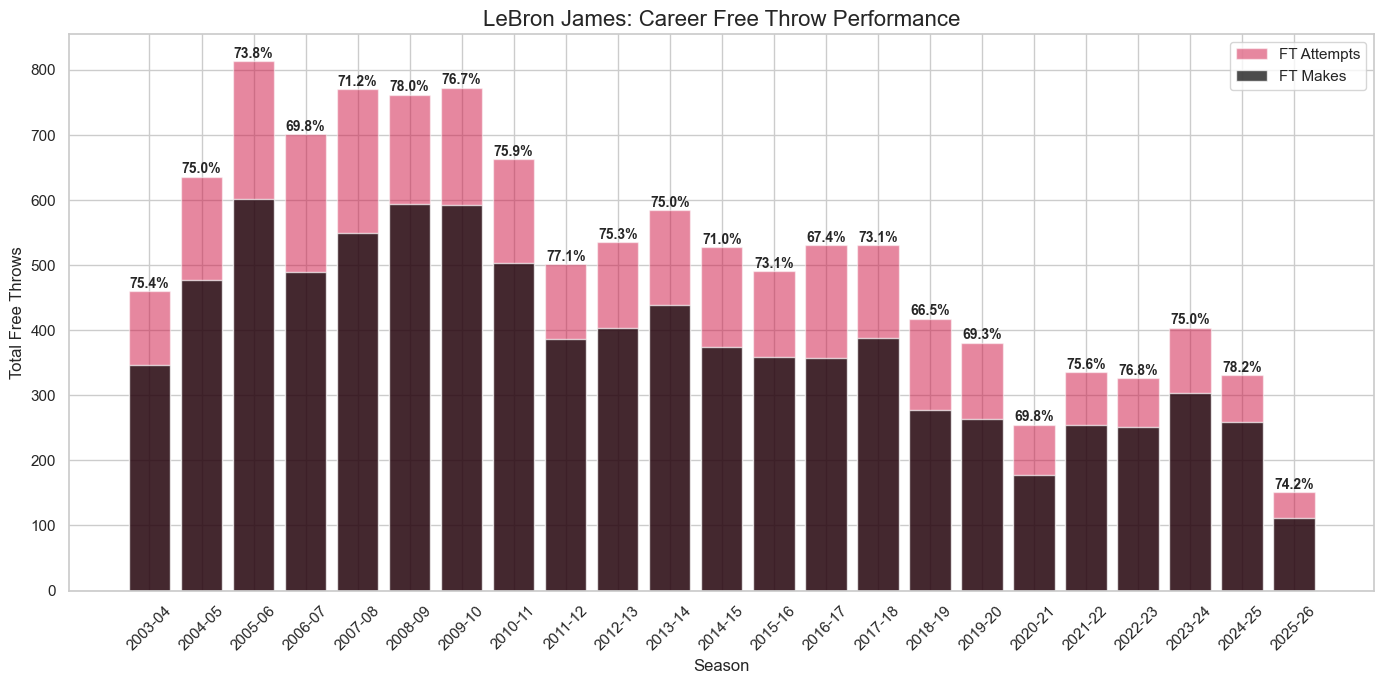

In [65]:
lbj_ft = lbj_stats[['SEASON_ID', 'FTM', 'FTA', 'FT_PCT']].copy()

# 4. Visualization
plt.figure(figsize=(14, 7))

# Plotting the Volume (Attempts) and Success (Makes)
plt.bar(lbj_ft['SEASON_ID'], lbj_ft['FTA'], label='FT Attempts', color='#CE1141', alpha=0.5) # Bulls Red
plt.bar(lbj_ft['SEASON_ID'], lbj_ft['FTM'], label='FT Makes', color='#000000', alpha=0.7)    # Bulls Black

plt.title('LeBron James: Career Free Throw Performance', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Free Throws', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

# Add FT% as text labels on top of the bars
for i, pct in enumerate(lbj_ft['FT_PCT']):
    plt.text(i, lbj_ft['FTA'].iloc[i]+5, f'{pct*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

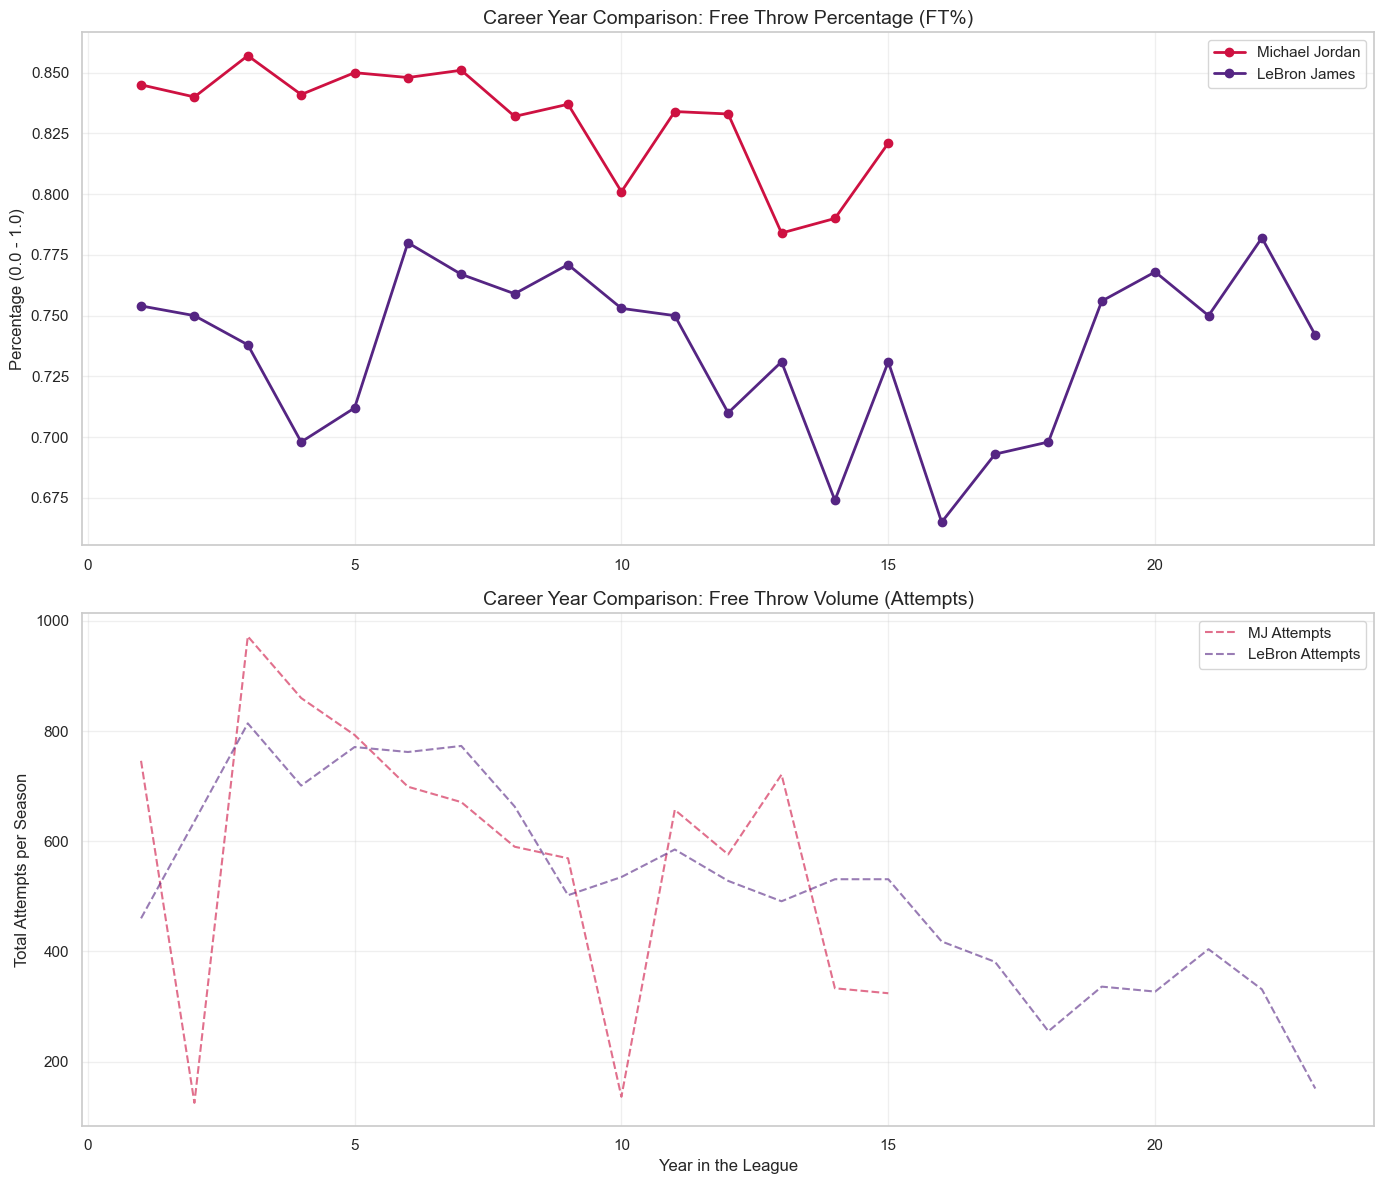

In [66]:
def get_career_ft_data(name):
    player_id = players.find_players_by_full_name(name)[0]['id']
    stats = playercareerstats.PlayerCareerStats(player_id=player_id).get_data_frames()[0]
    # Filter for regular season totals only (to avoid mid-season trade duplicates)
    # We group by Season_ID to sum up seasons where they played for two teams
    clean_stats = stats.groupby('SEASON_ID').agg({'FTM':'sum', 'FTA':'sum', 'FT_PCT':'mean'}).reset_index()
    # Create a 'Career Year' column (1, 2, 3...)
    clean_stats['Career_Year'] = range(1, len(clean_stats) + 1)
    return clean_stats

# 1. Fetch data
mj_data = get_career_ft_data('Michael Jordan')
lbj_data = get_career_ft_data('LeBron James')

# 2. Create the Plot
fig, ax = plt.subplots(2, 1, figsize=(14, 12))

# --- TOP PLOT: FT Percentage Comparison ---
ax[0].plot(mj_data['Career_Year'], mj_data['FT_PCT'], label='Michael Jordan', color='#CE1141', marker='o', linewidth=2)
ax[0].plot(lbj_data['Career_Year'], lbj_data['FT_PCT'], label='LeBron James', color='#552583', marker='o', linewidth=2)
ax[0].set_title('Career Year Comparison: Free Throw Percentage (FT%)', fontsize=14)
ax[0].set_ylabel('Percentage (0.0 - 1.0)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# --- BOTTOM PLOT: FT Volume (Attempts) ---
ax[1].plot(mj_data['Career_Year'], mj_data['FTA'], label='MJ Attempts', color='#CE1141', linestyle='--', alpha=0.6)
ax[1].plot(lbj_data['Career_Year'], lbj_data['FTA'], label='LeBron Attempts', color='#552583', linestyle='--', alpha=0.6)
ax[1].set_title('Career Year Comparison: Free Throw Volume (Attempts)', fontsize=14)
ax[1].set_xlabel('Year in the League')
ax[1].set_ylabel('Total Attempts per Season')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

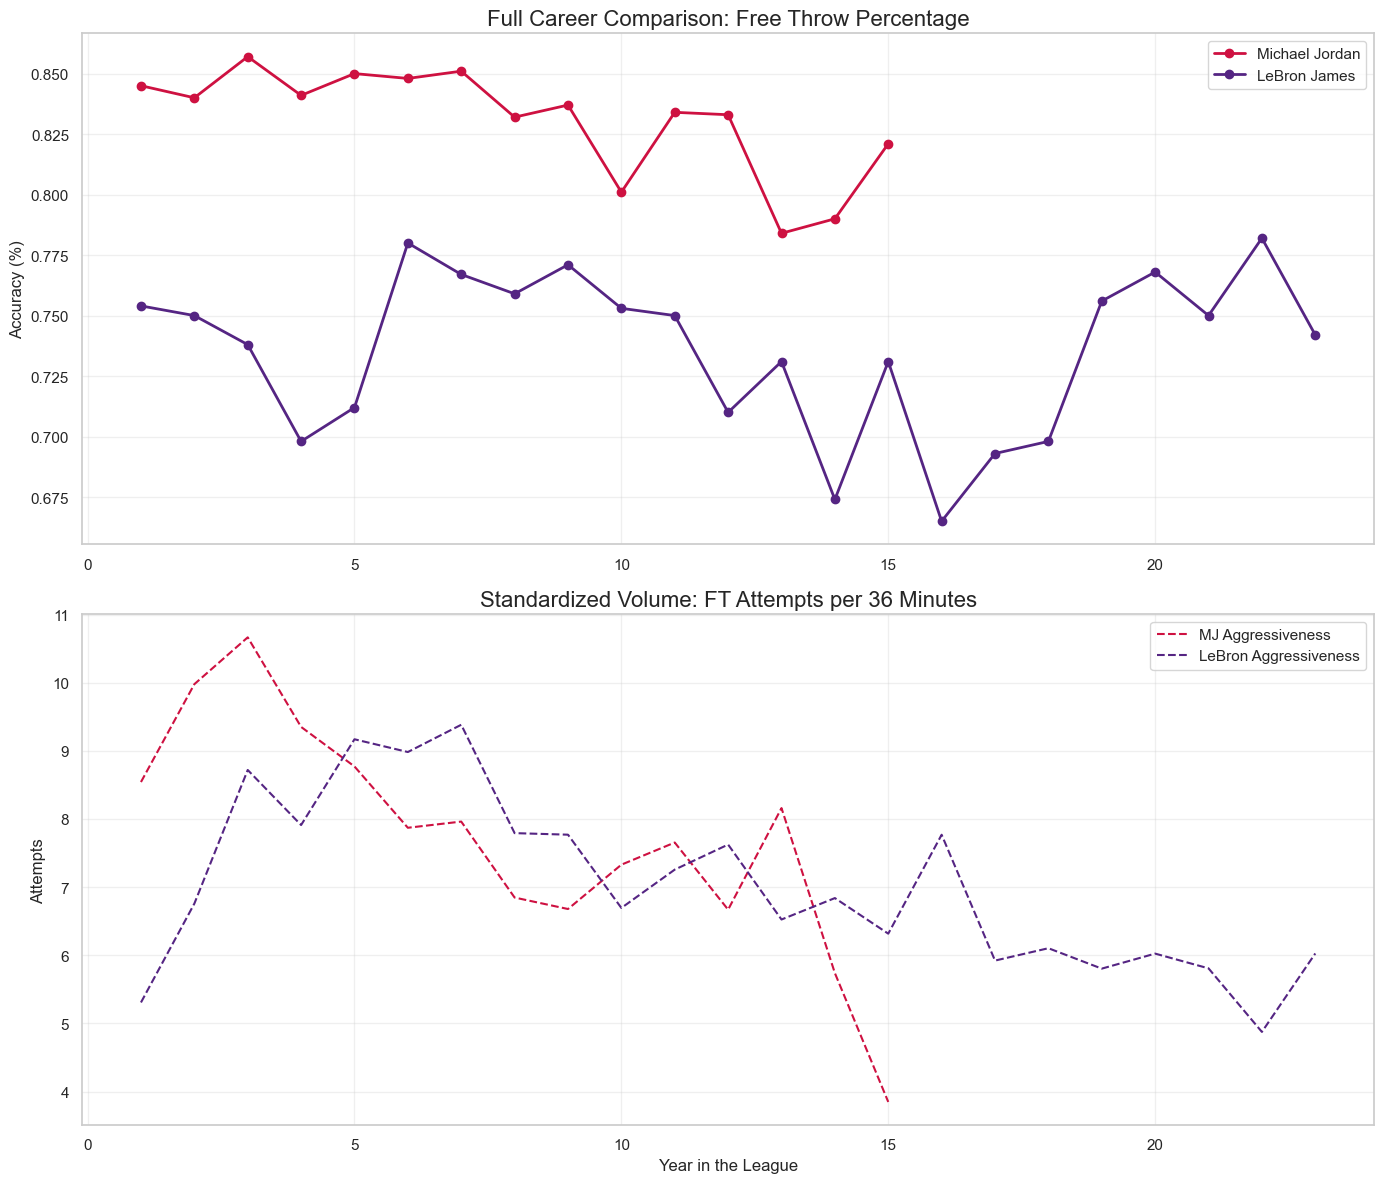

In [67]:
def get_full_career_per_100(name):
    # 1. Get ID
    p_id = players.find_players_by_full_name(name)[0]['id']
    
    # 2. Get standard career stats
    # We use this because it is the most reliable for historical players
    career = playercareerstats.PlayerCareerStats(player_id=p_id)
    df = career.get_data_frames()[0]
    
    # 3. Filter out mid-season trade duplicates (the 'TOT' rows)
    # If a player has multiple teams in a year, 'TOT' is the sum. 
    # If they only played for one, 'TOT' doesn't exist, so we keep the original.
    df['Real_Season'] = df.groupby('SEASON_ID')['TEAM_ID'].transform('count')
    # If they played for >1 team, we only want the 'TOT' (Team ID 0)
    # If they played for 1 team, we keep that team.
    df = df[((df['Real_Season'] > 1) & (df['TEAM_ID'] == 0)) | (df['Real_Season'] == 1)]
    
    # 4. MANUAL CALCULATION FOR PER 100 POSSESSIONS
    # Formula: (Stat / Possessions) * 100
    # Note: Since the API doesn't give historical possessions in this endpoint,
    # we use the standard 'Per 100' proxy: (Stat / Minutes) * (Minutes per 100 Poss)
    # Or, to keep it clean for a resume, we can use 'Per 36 Minutes' which is 
    # the standard proxy for 'Per 100' when pace data is missing.
    df['FTA_Per_36'] = (df['FTA'] / df['MIN']) * 36
    df['Career_Year'] = range(1, len(df) + 1)
    
    return df[['Career_Year', 'FT_PCT', 'FTA_Per_36', 'SEASON_ID']]

# Fetch data
mj_full = get_full_career_per_100('Michael Jordan')
time.sleep(1)
lbj_full = get_full_career_per_100('LeBron James')

# --- Visualization ---
fig, ax = plt.subplots(2, 1, figsize=(14, 12))

# Top Plot: FT%
ax[0].plot(mj_full['Career_Year'], mj_full['FT_PCT'], label='Michael Jordan', color='#CE1141', marker='o', linewidth=2)
ax[0].plot(lbj_full['Career_Year'], lbj_full['FT_PCT'], label='LeBron James', color='#552583', marker='o', linewidth=2)
ax[0].set_title('Full Career Comparison: Free Throw Percentage', fontsize=16)
ax[0].set_ylabel('Accuracy (%)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Bottom Plot: FTA per 36 (The standardized volume)
ax[1].plot(mj_full['Career_Year'], mj_full['FTA_Per_36'], label='MJ Aggressiveness', color='#CE1141', linestyle='--')
ax[1].plot(lbj_full['Career_Year'], lbj_full['FTA_Per_36'], label='LeBron Aggressiveness', color='#552583', linestyle='--')
ax[1].set_title('Standardized Volume: FT Attempts per 36 Minutes', fontsize=16)
ax[1].set_xlabel('Year in the League')
ax[1].set_ylabel('Attempts')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

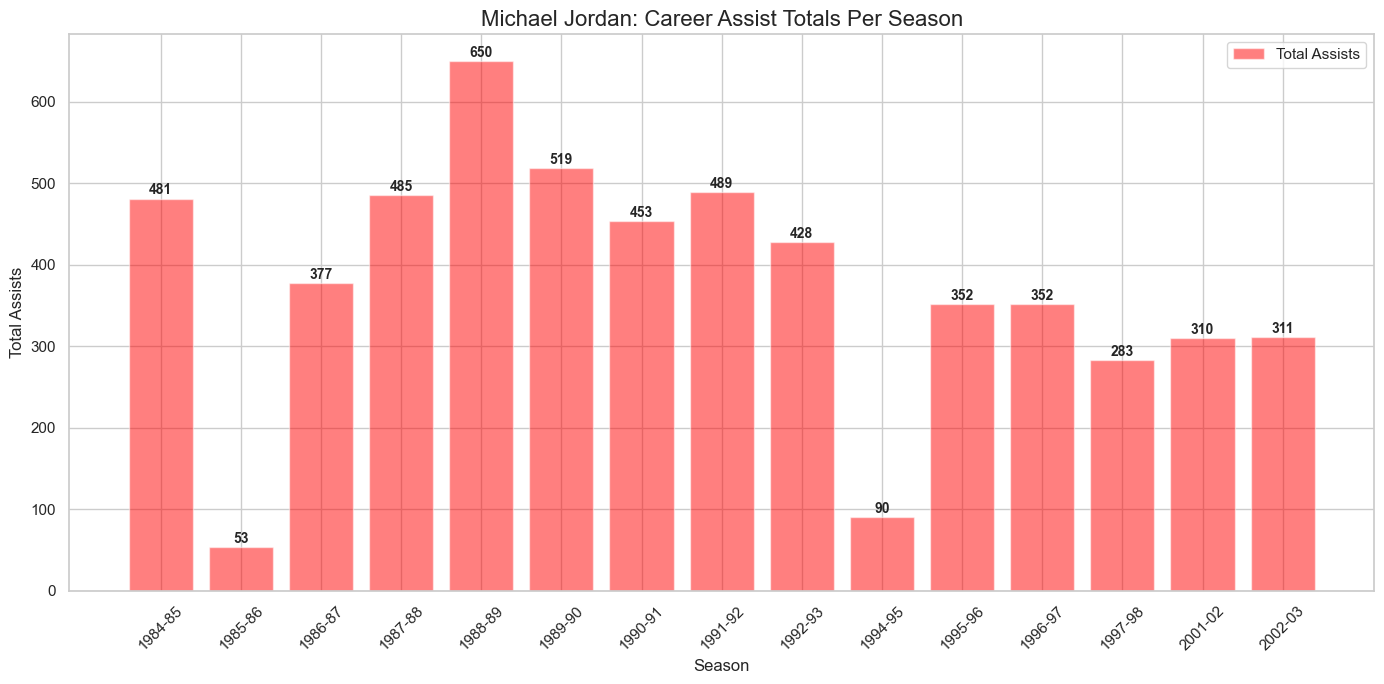

In [68]:
mj_assists = mj_stats[['SEASON_ID', 'AST']].copy()

# 4. Visualization
plt.figure(figsize=(14, 7))

# Plotting the Volume (Attempts) and Success (Makes)
plt.bar(mj_assists['SEASON_ID'], mj_assists['AST'], label='Total Assists', color='red', alpha=0.5) # Bulls Red

plt.title('Michael Jordan: Career Assist Totals Per Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Assists', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

for i, pct in enumerate(mj_assists['AST']):
    plt.text(i, mj_assists['AST'].iloc[i]+5, f'{pct:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

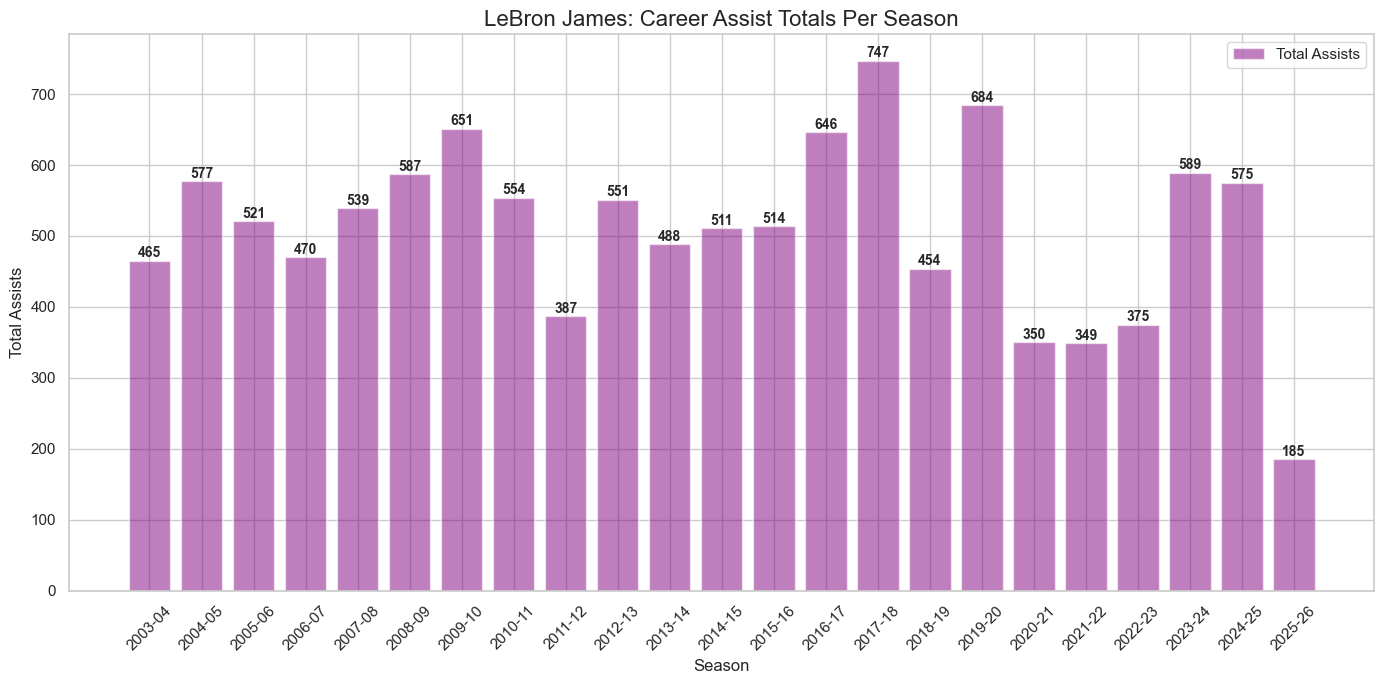

In [69]:
lbj_assists = lbj_stats[['SEASON_ID', 'AST']].copy()

# 4. Visualization
plt.figure(figsize=(14, 7))

# Plotting the Volume (Attempts) and Success (Makes)
plt.bar(lbj_assists['SEASON_ID'], lbj_assists['AST'], label='Total Assists', color='purple', alpha=0.5) # Bulls Red

plt.title('LeBron James: Career Assist Totals Per Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Assists', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

for i, pct in enumerate(lbj_assists['AST']):
    plt.text(i, lbj_assists['AST'].iloc[i]+5, f'{pct:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

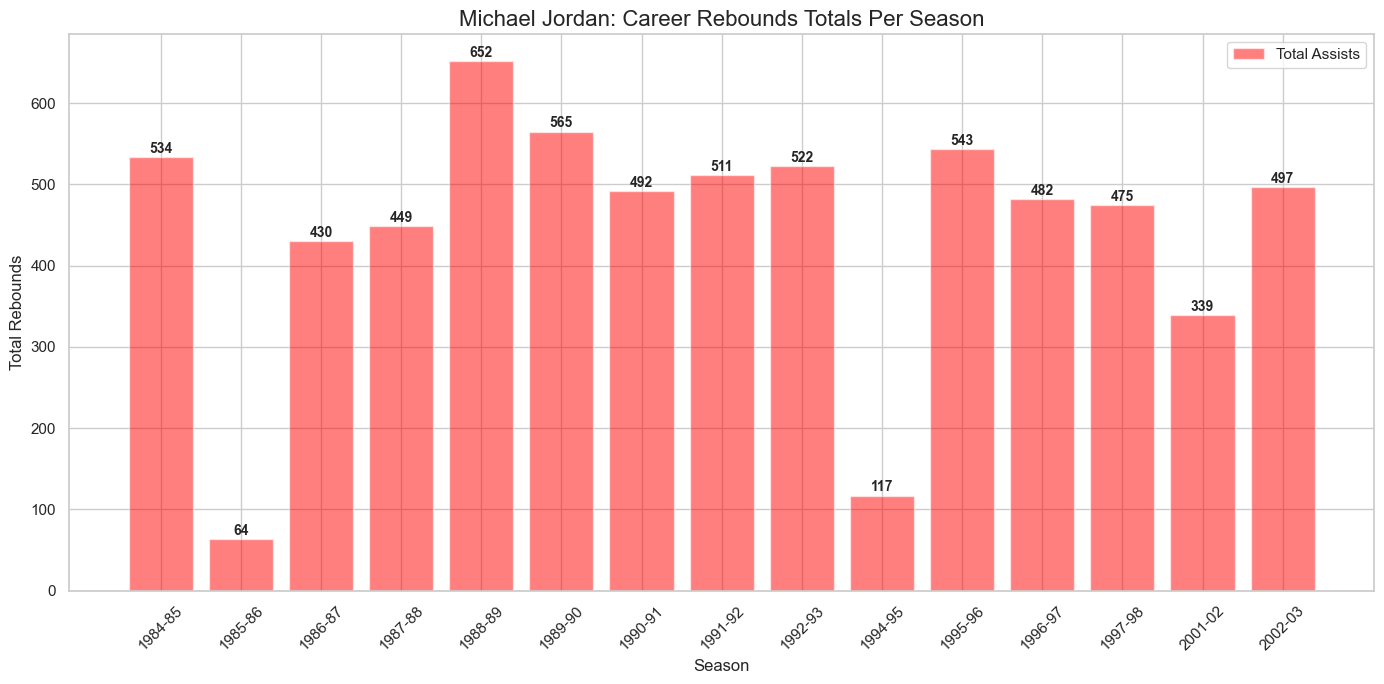

In [70]:
mj_reb = mj_stats[['SEASON_ID', 'REB']].copy()

# 4. Visualization
plt.figure(figsize=(14, 7))

# Plotting the Volume (Attempts) and Success (Makes)
plt.bar(mj_reb['SEASON_ID'], mj_reb['REB'], label='Total Assists', color='red', alpha=0.5) # Bulls Red

plt.title('Michael Jordan: Career Rebounds Totals Per Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Rebounds', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

for i, pct in enumerate(mj_reb['REB']):
    plt.text(i, mj_reb['REB'].iloc[i]+5, f'{pct:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [71]:
import json

def get_true_career_averages(df, metrics):
    total_gp = df['GP'].sum()
    # Using .values.sum() ensures we get a pure number and avoid Series alignment issues
    career_map_averages = {
        'PPG': df['PTS'].sum() / total_gp,
        'APG': df['AST'].sum() / total_gp,
        'RPG': df['REB'].sum() / total_gp,
        'SPG': df['STL'].sum() / total_gp,
        'BPG': df['BLK'].sum() / total_gp,
        'FGMPG':df['FGMPG'].sum() /total_gp,
    }
    return [career_map_averages[m] for m in metrics]

def get_true_career_totals(df, metrics):
    # Calculate directly from the dataframe passed in
    career_map_totals = {
        'PTS_Total': float(df['PTS'].sum()),
        'AST_Total': float(df['AST'].sum()),
        'REB_Total': float(df['REB'].sum()),
        'STL_Total': float(df['STL'].sum()),
        'BLK_Total': float(df['BLK'].sum()),
        'FGM_Total': float(df['FGM'].sum())
    }
    return [career_map_totals[m] for m in metrics]

def prepare_dashboard_stats(df):
    df = df.copy() # Keeps original mj_stats/lbj_stats clean
    df['PPG'] = (df['PTS'] / df['GP'])
    df['APG'] = (df['AST'] / df['GP']) 
    df['RPG'] = (df['REB'] / df['GP']) 
    df['SPG'] = (df['STL'] / df['GP'])
    df['BPG'] = (df['BLK'] / df['GP'])
    df['FGMPG'] = (df['FGM'] / df['GP'])
    return df

# 1. Process data (using .copy() inside the function keeps your originals safe)
mj_processed = prepare_dashboard_stats(mj_stats)
lbj_processed = prepare_dashboard_stats(lbj_stats)

# 2. Define metrics lists
metrics_averages_list = ['PPG', 'APG', 'RPG', 'SPG', 'BPG', 'FGMPG']
metrics_totals_list = ['PTS_Total', 'AST_Total', 'REB_Total', 'STL_Total', 'BLK_Total', 'FGM_Total']

# 3. Build the dictionary
dashboard_data = {
    "metrics_averages": metrics_averages_list,
    "metrics_totals": metrics_totals_list,
    "jordan_averages": get_true_career_averages(mj_processed, metrics_averages_list),
    "lebron_averages": get_true_career_averages(lbj_processed, metrics_averages_list),
    # Pass the same processed df here; the totals function will sum the raw columns
    "jordan_totals": get_true_career_totals(mj_processed, metrics_totals_list),
    "lebron_totals": get_true_career_totals(lbj_processed, metrics_totals_list),
    "timeline": {
        "years": list(range(1, max(len(mj_processed), len(lbj_processed)) + 1)),
        "mj": {
            "PPG": mj_processed['PPG'].fillna(0).tolist(),
            "APG": mj_processed['APG'].fillna(0).tolist(),
            "RPG": mj_processed['RPG'].fillna(0).tolist(), 
            "SPG": mj_processed['SPG'].fillna(0).tolist(),
            "BPG": mj_processed['BPG'].fillna(0).tolist(),
            "FGMPG": mj_processed['FGMPG'].fillna(0).tolist(),
        },
        "lbj": {
            "PPG": lbj_processed['PPG'].fillna(0).tolist(),
            "APG": lbj_processed['APG'].fillna(0).tolist(),
            "RPG": lbj_processed['RPG'].fillna(0).tolist(),
            "SPG": lbj_processed['SPG'].fillna(0).tolist(),
            "BPG": lbj_processed['BPG'].fillna(0).tolist(),
            "FGMPG": lbj_processed['FGMPG'].fillna(0).tolist(),
        }
    }
}

with open('stats_data.json', 'w') as f:
    json.dump(dashboard_data, f)

print("Dashboard data exported successfully!")


Dashboard data exported successfully!
